In [25]:
import scipy.io

mat1 = scipy.io.loadmat('./kernel_1.mat')
mat2 = scipy.io.loadmat('./kernel_2.mat')
mat3 = scipy.io.loadmat('./kernel_3.mat')
mat4 = scipy.io.loadmat('./kernel_4.mat')
print(mat1.keys())  # See what's inside the file


dict_keys(['__header__', '__version__', '__globals__', 'kernel'])


In [26]:
data1 = mat1['kernel']
data2 = mat2['kernel']
data3 = mat3['kernel']
data4 = mat4['kernel']
print(data1.shape)
print(data2.shape)
print(data3.shape)
print(data4.shape)

(9, 9)
(13, 13)
(9, 9)
(7, 7)


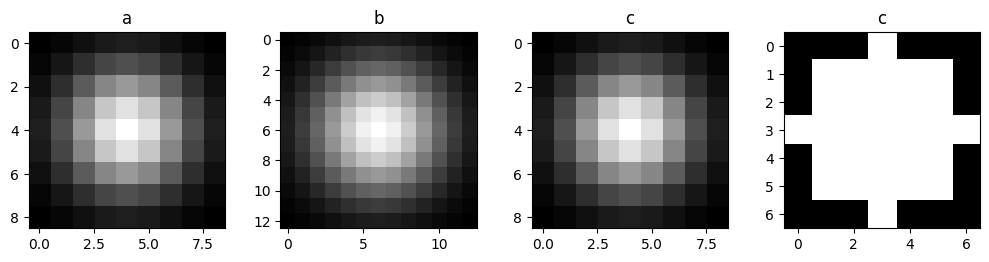

In [27]:
import matplotlib.pyplot as plt

# Assuming data1, data2, and data3 are loaded as 2D arrays
fig, axes = plt.subplots(1, 4, figsize=(10, 4))

# Plot each kernel
axes[0].imshow(data1, cmap='gray')
axes[0].set_title('a')
# axes[0].axis('off')

axes[1].imshow(data2, cmap='gray')
axes[1].set_title('b')
# axes[1].axis('off')

axes[2].imshow(data3, cmap='gray')
axes[2].set_title('c')
# axes[2].axis('off')

axes[3].imshow(data4, cmap='gray')
axes[3].set_title('c')
# axes[2].axis('off')

plt.tight_layout()
plt.savefig('kernels')
plt.show()

In [28]:
import numpy as np

mean = np.mean(data1)
std = np.std(data1)
min_val = np.min(data1)
max_val = np.max(data1)

print(f"Mean: {mean:.6f}")
print(f"Std Dev: {std:.6f}")
print(f"Min: {min_val:.6f}")
print(f"Max: {max_val:.6f}")


Mean: 0.012346
Std Dev: 0.010794
Min: 0.000763
Max: 0.041683


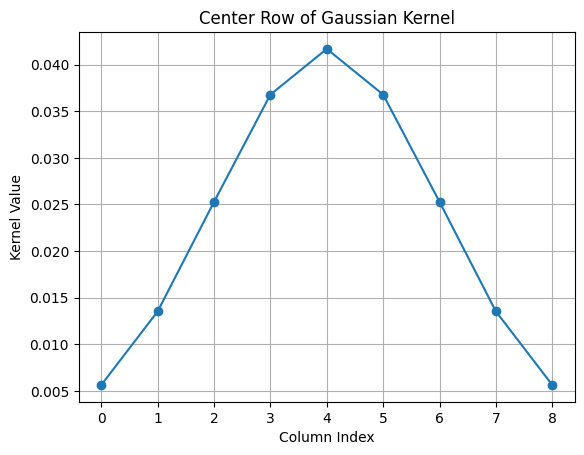

In [29]:
import matplotlib.pyplot as plt

center_row = data1.shape[0] // 2  # Row 4 in 9x9
plt.plot(data1[center_row, :], marker='o')
plt.title("Center Row of Gaussian Kernel")
plt.xlabel("Column Index")
plt.ylabel("Kernel Value")
plt.grid(True)
plt.show()


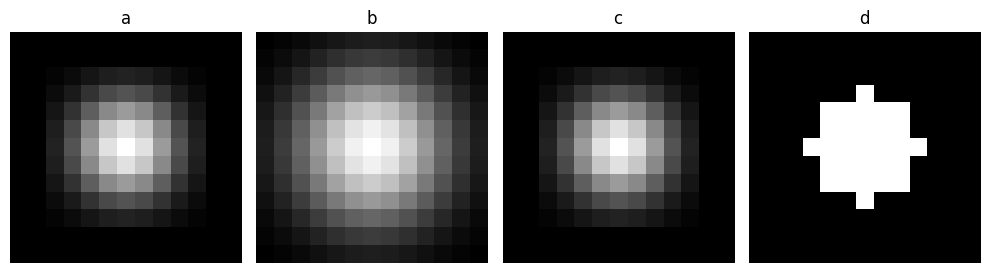

In [30]:
import numpy as np

def pad_to_shape(arr, target_shape):
    padded = np.zeros(target_shape)
    h, w = arr.shape
    H, W = target_shape
    y0 = (H - h) // 2
    x0 = (W - w) // 2
    padded[y0:y0+h, x0:x0+w] = arr
    return padded
target_shape = (
    max(data1.shape[0], data2.shape[0], data3.shape[0], data4.shape[0]),
    max(data1.shape[1], data2.shape[1], data3.shape[1], data4.shape[1])
)

p1 = pad_to_shape(data1, target_shape)
p2 = pad_to_shape(data2, target_shape)
p3 = pad_to_shape(data3, target_shape)
p4 = pad_to_shape(data4, target_shape)
fig, axes = plt.subplots(1, 4, figsize=(10, 4))

for ax, data, title in zip(
    axes, [p1, p2, p3, p4], ['a', 'b', 'c', 'd']
):
    ax.imshow(data, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.savefig('kernels.png', dpi=300)
plt.show()
